In [11]:
import numpy as np
import spoa
import math

# --- 1. Generate Synthetic DNA (N=15, L=50) ---
# Scenario: 7 reads have a linked mutation (T at pos 10, G at pos 30)
# 8 reads are wild-type (A at pos 10, C at pos 30)
ref = "A" * 50
sequences = []
for i in range(15):
    s = list(ref)
    if i < 7: # Sub-population 1
        s[10], s[30] = "T", "G"
    else:     # Sub-population 2
        s[10], s[30] = "A", "C"
    # Add minor random noise (0.1% error)
    for j in range(len(s)):
        if np.random.random() < 0.001:
            s[j] = np.random.choice(list("ACGT"))
    sequences.append("".join(s))

# --- 2. Perform MSA using pyspoa ---
_, msa_list = spoa.poa(sequences, algorithm = 1)

# Map characters to integers for MI (A:0, C:1, G:2, T:3)
char_map = {b: i for i, b in enumerate("ACGT")}
msa_int = np.array([[char_map.get(b, 4) for b in s] for s in msa_list], dtype=np.int8)

# --- 3. Calculate Raw MI between specific columns ---
def calc_mi_raw(col_a, col_b):
    n = len(col_a)
    counts = np.zeros((4, 4))
    m_a, m_b = np.zeros(4), np.zeros(4)
    for i in range(n):
        u, v = col_a[i], col_b[i]
        if u < 4 and v < 4:
            counts[u, v] += 1
            m_a[u] += 1
            m_b[v] += 1
    mi = 0.0
    for r in range(4):
        for c in range(4):
            if counts[r, c] > 0:
                p_rc = counts[r, c] / n
                p_r, p_c = m_a[r] / n, m_b[c] / n
                mi += p_rc * math.log2(p_rc / (p_r * p_c))
    return mi

# --- 4. Results ---
mi_signal = calc_mi_raw(msa_int[:, 10], msa_int[:, 30])
mi_noise  = calc_mi_raw(msa_int[:, 10], msa_int[:, 15])

print(f"MI (Linked sites 10 & 30): {mi_signal:.4f} bits")
print(f"MI (Unlinked sites 10 & 15): {mi_noise:.4f} bits")

# --- 5. Calculate Total MI (Sum of all unique pairs) ---
L_msa = msa_int.shape[1]
total_mi = 0.0

# Nested loop to calculate every unique pair (i < j)
for i in range(L_msa):
    for j in range(i + 1, L_msa):
        # We only care about columns that have variance (n_var > 0)
        # but the function handles static columns fine (returns 0.0)
        total_mi += calc_mi_raw(msa_int[:, i], msa_int[:, j])

print(f"Total Mutual Information in MSA: {total_mi:.4f} bits")

MI (Linked sites 10 & 30): 0.9968 bits
MI (Unlinked sites 10 & 15): 0.0000 bits
Total Mutual Information in MSA: 0.9968 bits


In [42]:
import numpy as np
import spoa
import math
from numba import njit

# --- 1. LOW-LEVEL HELPERS ---

@njit(fastmath=True)
def popcount64(x):
    x = np.uint64(x)
    x -= (x >> np.uint64(1)) & np.uint64(0x5555555555555555)
    x = (x & np.uint64(0x3333333333333333)) + ((x >> np.uint64(2)) & np.uint64(0x3333333333333333))
    x = (x + (x >> np.uint64(4))) & np.uint64(0x0F0F0F0F0F0F0F0F)
    return (x * np.uint64(0x0101010101010101)) >> np.uint64(56)

@njit(fastmath=True)
def _score_bitwise_internal(bitmaps, n_chunks, L, n_var, lut, top_pct, bottom_pct,
                            variant_indices, exclusion_dist):
    N = lut.shape[0] - 1
    inv_N = 1.0 / float(N)
    
    row_mis = np.zeros(n_var, dtype=np.float32)
    counts = np.zeros((4, 4), dtype=np.int32)
    marg_i = np.zeros(4, dtype=np.int32)
    marg_j = np.zeros(4, dtype=np.int32)

    for i in range(n_var):
        phys_i = variant_indices[i] 
        best_mi_for_i = 0.0
        
        # Marginals Row I
        marg_i[:] = 0
        for b in range(4):
            c = 0
            for k in range(n_chunks):
                v = bitmaps[b, i, k]
                if v > 0: c += popcount64(v)
            marg_i[b] = c

        for j in range(n_var):
            if i == j: continue
            phys_j = variant_indices[j]
            
            # Distance Filter
            dist = phys_i - phys_j
            if dist < 0: dist = -dist
            if dist <= exclusion_dist: continue

            # Marginals Row J
            marg_j[:] = 0
            for b in range(4):
                c = 0
                for k in range(n_chunks):
                    v = bitmaps[b, j, k]
                    if v > 0: c += popcount64(v)
                marg_j[b] = c

            # Intersection
            counts[:] = 0
            total_overlap = 0
            for b1 in range(4):
                if marg_i[b1] == 0: continue
                for b2 in range(4):
                    if marg_j[b2] == 0: continue
                    c_xy = 0
                    for k in range(n_chunks):
                        bits = bitmaps[b1, i, k] & bitmaps[b2, j, k]
                        if bits > 0: c_xy += popcount64(bits)
                    counts[b1, b2] = c_xy
                    total_overlap += c_xy

            # MI Calc (Bits)
            mi_val = 0.0
            for b1 in range(4):
                p_x = marg_i[b1] * inv_N
                if p_x == 0: continue
                for b2 in range(4):
                    p_y = marg_j[b2] * inv_N
                    if p_y == 0: continue
                    c_xy = counts[b1, b2]
                    if c_xy > 0: 
                        p_xy = c_xy * inv_N
                        mi_val += p_xy * np.log2(p_xy / (p_x * p_y))

            if mi_val > best_mi_for_i:
                best_mi_for_i = mi_val

        row_mis[i] = best_mi_for_i
    
    # [CHANGED] Median-Subtracted Sum logic
    if n_var == 0: return 0.0
    
    noise_floor = np.median(row_mis)
    signal_sum = 0.0
    for val in row_mis:
        diff = val - noise_floor
        if diff > 0:
            signal_sum += diff
            
    return signal_sum

# --- 2. CONVENTIONAL REFERENCE ---

def _score_conventional(msa_int, var_indices, exclusion_dist):
    n_members, _ = msa_int.shape
    n_var = len(var_indices)
    inv_N = 1.0 / n_members
    row_mis = np.zeros(n_var, dtype=np.float32)
    
    for i in range(n_var):
        phys_i = var_indices[i]
        col_i = msa_int[:, phys_i]
        best_mi = 0.0
        
        for j in range(n_var):
            if i == j: continue
            phys_j = var_indices[j]
            if abs(phys_i - phys_j) <= exclusion_dist: continue
            col_j = msa_int[:, phys_j]
            
            counts = np.zeros((5, 5), dtype=np.int32) 
            for k in range(n_members):
                u, v = col_i[k], col_j[k]
                if u < 4 and v < 4: counts[u, v] += 1
            
            marg_a = np.sum(counts, axis=1)
            marg_b = np.sum(counts, axis=0)
            valid_n = np.sum(counts) 
            if valid_n == 0: continue
            inv_valid = 1.0 / valid_n
            
            mi = 0.0
            for r in range(4):
                p_r = marg_a[r] * inv_valid
                if p_r == 0: continue
                for c in range(4):
                    p_c = marg_b[c] * inv_valid
                    if p_c == 0: continue
                    p_rc = counts[r, c] * inv_valid
                    if p_rc > 0:
                        mi += p_rc * np.log2(p_rc / (p_r * p_c))
            
            if mi > best_mi: best_mi = mi
        
        row_mis[i] = best_mi

    # [CHANGED] Median-Subtracted Sum logic
    if n_var == 0: return 0.0
    noise_floor = np.median(row_mis)
    signal_sum = 0.0
    for val in row_mis:
        diff = val - noise_floor
        if diff > 0: signal_sum += diff
    return signal_sum

# --- 3. TEST HARNESS ---
def run_comparison_test():
    print(f"{'METRIC':<20} | {'VALUE':<10}")
    print("-" * 35)

    ref = "A" * 50
    sequences = []
    for i in range(16):
        s = list(ref)
        if i < 8: 
             s[10], s[30] = "T", "G"
             # s[10], s[30], s[45] = "T", "G", "G"
        else:     
             s[10], s[30] = "A", "C"
             # s[10], s[30], s[45] = "A", "C", "A"
        sequences.append("".join(s))

    _, msa_list = spoa.poa(sequences, algorithm=1)
    
    char_map = {b: i for i, b in enumerate("ACGT")}
    msa_int = np.array([[char_map.get(b, 4) for b in s] for s in msa_list], dtype=np.int8)
    L = msa_int.shape[1]

    # Identify Variants
    var_indices = []
    for c in range(L):
        unique_bases = np.unique(msa_int[:, c])
        valid_bases = unique_bases[unique_bases < 4]
        if len(valid_bases) > 1:
            var_indices.append(c)
    
    var_indices = np.array(var_indices, dtype=np.int32)
    n_var = len(var_indices)
    
    print(f"Num Variants Found : {n_var}")
    print(f"Variant Indices    : {var_indices}")

    # --- RUN CONVENTIONAL ---
    score_conv = _score_conventional(msa_int, var_indices, exclusion_dist=5)
    print(f"Conventional Score : {score_conv:.5f} bits")

    # --- RUN BITWISE ---
    n_members = 16
    n_chunks = (n_members + 63) // 64
    bitmaps = np.zeros((4, n_var, n_chunks), dtype=np.uint64)
    for i, col_idx in enumerate(var_indices):
        for r in range(n_members):
            base = msa_int[r, col_idx]
            if base < 4:
                chunk = r // 64
                pos = r % 64
                bitmaps[base, i, chunk] |= (np.uint64(1) << np.uint64(pos))

    lut = np.zeros((n_members+1, n_members+1, n_members+1))
    
    score_bit = _score_bitwise_internal(
        bitmaps, n_chunks, L, n_var, lut, 
        0.0, 0.0,
        var_indices, exclusion_dist=5
    )
    print(f"Bitwise Score      : {score_bit:.5f} bits")
    
    diff = abs(score_conv - score_bit)
    if diff < 1e-4:
        print("\n>> SUCCESS: Scores Match!")
    else:
        print(f"\n>> FAILURE: Difference is {diff:.5f}")

run_comparison_test()

METRIC               | VALUE     
-----------------------------------
Num Variants Found : 2
Variant Indices    : [10 30]
Conventional Score : 0.00000 bits
Bitwise Score      : 0.00000 bits

>> SUCCESS: Scores Match!


In [65]:
import numpy as np
import spoa
import math
from numba import njit
import random

# --- 1. LOW-LEVEL HELPERS ---

@njit(fastmath=True)
def popcount64(x):
    x = np.uint64(x)
    x -= (x >> np.uint64(1)) & np.uint64(0x5555555555555555)
    x = (x & np.uint64(0x3333333333333333)) + ((x >> np.uint64(2)) & np.uint64(0x3333333333333333))
    x = (x + (x >> np.uint64(4))) & np.uint64(0x0F0F0F0F0F0F0F0F)
    return (x * np.uint64(0x0101010101010101)) >> np.uint64(56)

import numpy as np
from numba import njit
import math

# Assuming popcount64 is available in your scope (e.g. via intrinsic or import)
# form numba.core.intrinsics import bit_count # If needed
import numpy as np
from numba import njit
import math

@njit(fastmath=True)
def _score_bitwise_internal(bitmaps, n_chunks, L, n_var, lut, top_pct, bottom_pct,
                            variant_indices, exclusion_dist, threshold=0.2):
    # N is the total number of sequences (including those with gaps)
    N = lut.shape[0] - 1
    inv_N = 1.0 / float(N)
    
    max_var_pairs = (n_var * (n_var - 1)) // 2
    if max_var_pairs == 0: return 0.0
    
    pairwise_mis = np.zeros(max_var_pairs, dtype=np.float32)
    pair_count = 0

    # 5x5 Matrix for A, C, G, T, Gap
    counts = np.zeros((5, 5), dtype=np.int32)
    marg_i = np.zeros(5, dtype=np.int32)
    marg_j = np.zeros(5, dtype=np.int32)

    for i in range(n_var):
        phys_i = variant_indices[i] 
        
        # --- 1. Marginals I (including Gap) ---
        marg_i[:] = 0
        sum_bases_i = 0
        for b in range(4):
            c = 0
            for k in range(n_chunks):
                v = bitmaps[b, i, k]
                if v > 0: c += popcount64(v)
            marg_i[b] = c
            sum_bases_i += c
        # The remainder are Gaps
        marg_i[4] = N - sum_bases_i

        for j in range(i + 1, n_var):
            phys_j = variant_indices[j]
            dist = phys_i - phys_j
            if dist < 0: dist = -dist
            if dist <= exclusion_dist: continue

            # --- 2. Marginals J (including Gap) ---
            marg_j[:] = 0
            sum_bases_j = 0
            for b in range(4):
                c = 0
                for k in range(n_chunks):
                    v = bitmaps[b, j, k]
                    if v > 0: c += popcount64(v)
                marg_j[b] = c
                sum_bases_j += c
            marg_j[4] = N - sum_bases_j

            # --- 3. Base-Base Intersections (4x4) ---
            # We only do heavy bitwise ops for the 4x4 bases
            counts[:] = 0
            for b1 in range(4):
                if marg_i[b1] == 0: continue
                for b2 in range(4):
                    if marg_j[b2] == 0: continue
                    c_xy = 0
                    for k in range(n_chunks):
                        bits = bitmaps[b1, i, k] & bitmaps[b2, j, k]
                        if bits > 0: c_xy += popcount64(bits)
                    counts[b1, b2] = c_xy

            # --- 4. Arithmetic Inference for Gaps ---
            # Instead of bitwise ops, we deduce the gap overlaps.
            
            # Fill Column 4 (Base I vs Gap J)
            # count(Base_I, Gap_J) = Total_Base_I - Sum(Base_I vs Bases_J)
            for b1 in range(4):
                if marg_i[b1] > 0:
                    row_sum_bases = 0
                    for b2 in range(4):
                        row_sum_bases += counts[b1, b2]
                    counts[b1, 4] = marg_i[b1] - row_sum_bases

            # Fill Row 4 (Gap I vs Base J)
            # count(Gap_I, Base_J) = Total_Base_J - Sum(Bases_I vs Base_J)
            for b2 in range(4):
                if marg_j[b2] > 0:
                    col_sum_bases = 0
                    for b1 in range(4):
                        col_sum_bases += counts[b1, b2]
                    counts[4, b2] = marg_j[b2] - col_sum_bases

            # Fill Corner (Gap I vs Gap J)
            # count(Gap_I, Gap_J) = Total_Gap_I - Sum(Gap_I vs Bases_J)
            gap_i_sum_bases = 0
            for b2 in range(4):
                gap_i_sum_bases += counts[4, b2]
            counts[4, 4] = marg_i[4] - gap_i_sum_bases

            # --- 5. MI Calculation (5x5) ---
            mi_val = 0.0
            for b1 in range(5): # Loop over 5 states
                p_x = marg_i[b1] * inv_N
                if p_x == 0: continue
                for b2 in range(5):
                    p_y = marg_j[b2] * inv_N
                    if p_y == 0: continue
                    
                    c_xy = counts[b1, b2]
                    if c_xy > 0: 
                        p_xy = c_xy * inv_N
                        mi_val += p_xy * math.log2(p_xy / (p_x * p_y))
            
            pairwise_mis[pair_count] = mi_val
            pair_count += 1
            
    if pair_count == 0: return 0.0
    
    valid_scores = pairwise_mis[:pair_count]

    # Median subtraction
    total_L_pairs = (L * (L - 1)) // 2
    implicit_zeros = total_L_pairs - pair_count
    
    if implicit_zeros > pair_count:
        noise_floor = 0.0
    else:
        noise_floor = np.median(valid_scores)
        
    signal_sum = 0.0
    for val in valid_scores:
        diff = val - noise_floor
        if diff > threshold:
            signal_sum += diff
            
    return signal_sum


import numpy as np
import math

def _score_conventional(msa_int, var_indices, exclusion_dist, threshold=0.2):
    n_members, L = msa_int.shape
    n_var = len(var_indices)
    
    # Global Probability is valid now because we include Gaps
    inv_N = 1.0 / n_members
    
    pairwise_mis = []
    
    # 5x5 buffer for A,C,G,T,Gap
    counts = np.zeros((5, 5), dtype=np.int32)
    
    for i in range(n_var):
        phys_i = var_indices[i]
        col_i = msa_int[:, phys_i]
        
        for j in range(i + 1, n_var):
            phys_j = var_indices[j]
            if abs(phys_i - phys_j) <= exclusion_dist: continue
            col_j = msa_int[:, phys_j]
            
            counts[:] = 0
            
            for k in range(n_members):
                u, v = col_i[k], col_j[k]
                # Assuming u, v are 0..4 (where 4 is gap)
                # If your data uses -1 for gap, adjust accordingly
                if u < 5 and v < 5: 
                    counts[u, v] += 1
            
            marg_a = np.sum(counts, axis=1)
            marg_b = np.sum(counts, axis=0)
            
            # valid_n should equal n_members if all chars are 0-4
            valid_n = np.sum(counts)
            if valid_n == 0: continue
            inv_valid = 1.0 / valid_n
            
            mi = 0.0
            for r in range(5): # Loop over 5 states
                p_r = marg_a[r] * inv_valid
                if p_r == 0: continue
                for c in range(5):
                    p_c = marg_b[c] * inv_valid
                    if p_c == 0: continue
                    p_rc = counts[r, c] * inv_valid
                    if p_rc > 0:
                        mi += p_rc * math.log2(p_rc / (p_r * p_c))
            
            pairwise_mis.append(mi)

    if not pairwise_mis: return 0.0
    
    valid_scores = np.array(pairwise_mis)
    pair_count = len(valid_scores)
    
    total_L_pairs = (L * (L - 1)) // 2
    implicit_zeros = total_L_pairs - pair_count

    if implicit_zeros > pair_count:
        noise_floor = 0.0
    else:
        noise_floor = np.median(valid_scores)
    
    signal_sum = 0.0
    for val in valid_scores:
        diff = val - noise_floor
        if diff > threshold:
            signal_sum += diff
            
    return signal_sum

# --- 3. TEST HARNESS ---
def run_comparison_test():
    print(f"{'METRIC':<20} | {'VALUE':<10}")
    print("-" * 35)

    ref = ''.join(random.choices("ACGT", k=50))
    sequences = []
    for i in range(16):
        s = list(ref)
        if i < 6: 
             s[10], s[30], s[45] = "T", "G", "T"
             # Uncomment to see score jump to ~3.0 (3 edges)
             # s[10], s[30], s[45] = "T", "G", "G"
        elif i < 8: 
             s[10], s[30], s[45] = "T", "G", "T"
        else:     
             s[10], s[30], s[45] = "A", "C", "A"
             # s[10], s[30], s[45] = "A", "C", "A"

        error_rate = 0.0
        for j in range(len(s)):
                # Don't overwrite the signal positions so we don't dilute the test
                if j not in [10, 30, 45]:
                    if np.random.random() < error_rate:
                        s[j] = np.random.choice(list("ACGT"))

        sequences.append("".join(s))

    _, msa_list = spoa.poa(sequences, algorithm=1)

    for l in msa_list:
        print(l)
    
    char_map = {b: i for i, b in enumerate("ACGT")}
    msa_int = np.array([[char_map.get(b, 4) for b in s] for s in msa_list], dtype=np.int8)
    L = msa_int.shape[1]

    # Identify Variants
    var_indices = []
    for c in range(L):
        unique_bases = np.unique(msa_int[:, c])
        valid_bases = unique_bases[unique_bases < 4]
        if len(valid_bases) > 1:
            var_indices.append(c)
    
    var_indices = np.array(var_indices, dtype=np.int32)
    n_var = len(var_indices)
    
    print(f"Num Variants Found : {n_var}")
    print(f"Variant Indices    : {var_indices}")

    # --- RUN CONVENTIONAL ---
    score_conv = _score_conventional(msa_int, var_indices, exclusion_dist=5)
    print(f"Conventional Score : {score_conv:.5f} bits")

    # --- RUN BITWISE ---
    n_members = 16
    n_chunks = (n_members + 63) // 64
    bitmaps = np.zeros((4, n_var, n_chunks), dtype=np.uint64)
    for i, col_idx in enumerate(var_indices):
        for r in range(n_members):
            base = msa_int[r, col_idx]
            if base < 4:
                chunk = r // 64
                pos = r % 64
                bitmaps[base, i, chunk] |= (np.uint64(1) << np.uint64(pos))

    lut = np.zeros((n_members+1, n_members+1, n_members+1))
    
    score_bit = _score_bitwise_internal(
        bitmaps, n_chunks, L, n_var, lut, 
        0.0, 0.0,
        var_indices, exclusion_dist=5
    )
    print(f"Bitwise Score      : {score_bit:.5f} bits")
    
    diff = abs(score_conv - score_bit)
    if diff < 1e-4:
        print("\n>> SUCCESS: Scores Match!")
    else:
        print(f"\n>> FAILURE: Difference is {diff:.5f}")

run_comparison_test()

METRIC               | VALUE     
-----------------------------------
CGCAAAAGCCTAAACCTACTTCTTTAAATAGAACAGTCAGTTCCGTGGTG
CGCAAAAGCCTAAACCTACTTCTTTAAATAGAACAGTCAGTTCCGTGGTG
CGCAAAAGCCTAAACCTACTTCTTTAAATAGAACAGTCAGTTCCGTGGTG
CGCAAAAGCCTAAACCTACTTCTTTAAATAGAACAGTCAGTTCCGTGGTG
CGCAAAAGCCTAAACCTACTTCTTTAAATAGAACAGTCAGTTCCGTGGTG
CGCAAAAGCCTAAACCTACTTCTTTAAATAGAACAGTCAGTTCCGTGGTG
CGCAAAAGCCTAAACCTACTTCTTTAAATAGAACAGTCAGTTCCGTGGTG
CGCAAAAGCCTAAACCTACTTCTTTAAATAGAACAGTCAGTTCCGTGGTG
CGCAAAAGCCAAAACCTACTTCTTTAAATACAACAGTCAGTTCCGAGGTG
CGCAAAAGCCAAAACCTACTTCTTTAAATACAACAGTCAGTTCCGAGGTG
CGCAAAAGCCAAAACCTACTTCTTTAAATACAACAGTCAGTTCCGAGGTG
CGCAAAAGCCAAAACCTACTTCTTTAAATACAACAGTCAGTTCCGAGGTG
CGCAAAAGCCAAAACCTACTTCTTTAAATACAACAGTCAGTTCCGAGGTG
CGCAAAAGCCAAAACCTACTTCTTTAAATACAACAGTCAGTTCCGAGGTG
CGCAAAAGCCAAAACCTACTTCTTTAAATACAACAGTCAGTTCCGAGGTG
CGCAAAAGCCAAAACCTACTTCTTTAAATACAACAGTCAGTTCCGAGGTG
Num Variants Found : 3
Variant Indices    : [10 30 45]
Conventional Score : 3.00000 bits
Bitwise Score      : 3.00

In [248]:
import numpy as np
from numba import njit
import math

@njit(fastmath=True)
def get_leading_eigenvalue_power_method(M, num_simulations=20):
    """
    Approximates the largest eigenvalue using Power Iteration.
    Strictly handles types to keep Numba happy (all float32).
    """
    n = M.shape[0]
    if n == 0: return 0.0
    
    # 1. Initialize as float32 to match Matrix M
    b_k = np.ones(n, dtype=np.float32)
    
    for _ in range(num_simulations):
        # 2. Dot product of two float32 arrays -> returns float32
        b_k1 = np.dot(M, b_k)
        
        # 3. Calculate Norm (accumulate in float64 for precision/safety)
        norm = 0.0
        for x in b_k1:
            norm += x*x
        norm = math.sqrt(norm)
        
        if norm < 1e-9: return 0.0
        
        # 4. Normalize
        inv_norm = 1.0 / norm  # This is float64
        
        # 5. CRITICAL FIX: Cast back to float32 immediately.
        # Otherwise, float32 * float64 -> float64, changing the variable type 
        # and breaking the loop in Numba.
        b_k = (b_k1 * inv_norm).astype(np.float32)

    # Rayleigh Quotient
    final_dot = np.dot(M, b_k)
    eigenvalue = np.dot(b_k, final_dot)
    
    return eigenvalue
    
# --- 1. LOW-LEVEL HELPERS ---
@njit(fastmath=True)
def popcount64(x):
    x = np.uint64(x)
    x -= (x >> np.uint64(1)) & np.uint64(0x5555555555555555)
    x = (x & np.uint64(0x3333333333333333)) + ((x >> np.uint64(2)) & np.uint64(0x3333333333333333))
    x = (x + (x >> np.uint64(4))) & np.uint64(0x0F0F0F0F0F0F0F0F)
    return (x * np.uint64(0x0101010101010101)) >> np.uint64(56)

@njit(fastmath=True)
def _score_bitwise_internal(bitmaps, n_chunks, L, n_var, lut, top_pct, bottom_pct,
                            variant_indices, exclusion_dist, 
                            threshold=0.2, denoise=False, spectral=True):
    # N is the total number of sequences (including those with gaps)
    N = lut.shape[0] - 1
    inv_N = 1.0 / float(N)
    
    # We maintain a full matrix now to support Spectral analysis if requested
    mi_matrix = np.zeros((n_var, n_var), dtype=np.float32)
    
    # We also track the list of valid pairs for Median calculation
    max_pairs = (n_var * (n_var - 1)) // 2
    temp_scores = np.zeros(max_pairs, dtype=np.float32)
    pair_count = 0

    # 5x5 Buffers for A, C, G, T, Gap
    counts = np.zeros((5, 5), dtype=np.int32)
    marg_i = np.zeros(5, dtype=np.int32)
    marg_j = np.zeros(5, dtype=np.int32)

    for i in range(n_var):
        phys_i = variant_indices[i] 
        
        # --- 1. Marginals I (including Gap) ---
        marg_i[:] = 0
        sum_bases_i = 0
        for b in range(4):
            c = 0
            for k in range(n_chunks):
                v = bitmaps[b, i, k]
                if v > 0: c += popcount64(v)
            marg_i[b] = c
            sum_bases_i += c
        marg_i[4] = N - sum_bases_i

        for j in range(i + 1, n_var):
            phys_j = variant_indices[j]
            dist = phys_i - phys_j
            if dist < 0: dist = -dist
            if dist <= exclusion_dist: continue

            # --- 2. Marginals J (including Gap) ---
            marg_j[:] = 0
            sum_bases_j = 0
            for b in range(4):
                c = 0
                for k in range(n_chunks):
                    v = bitmaps[b, j, k]
                    if v > 0: c += popcount64(v)
                marg_j[b] = c
                sum_bases_j += c
            marg_j[4] = N - sum_bases_j

            # --- 3. Base-Base Intersections (4x4) ---
            counts[:] = 0
            for b1 in range(4):
                if marg_i[b1] == 0: continue
                for b2 in range(4):
                    if marg_j[b2] == 0: continue
                    c_xy = 0
                    for k in range(n_chunks):
                        bits = bitmaps[b1, i, k] & bitmaps[b2, j, k]
                        if bits > 0: c_xy += popcount64(bits)
                    counts[b1, b2] = c_xy

            # --- 4. Arithmetic Inference for Gaps ---
            # Column 4 (Base I vs Gap J)
            for b1 in range(4):
                if marg_i[b1] > 0:
                    row_sum_bases = 0
                    for b2 in range(4):
                        row_sum_bases += counts[b1, b2]
                    counts[b1, 4] = marg_i[b1] - row_sum_bases

            # Row 4 (Gap I vs Base J)
            for b2 in range(4):
                if marg_j[b2] > 0:
                    col_sum_bases = 0
                    for b1 in range(4):
                        col_sum_bases += counts[b1, b2]
                    counts[4, b2] = marg_j[b2] - col_sum_bases

            # Corner (Gap I vs Gap J)
            gap_i_sum_bases = 0
            for b2 in range(4):
                gap_i_sum_bases += counts[4, b2]
            counts[4, 4] = marg_i[4] - gap_i_sum_bases

            # --- 5. MI Calculation (5x5) ---
            mi_val = 0.0
            for b1 in range(5):
                p_x = marg_i[b1] * inv_N
                if p_x == 0: continue
                for b2 in range(5):
                    p_y = marg_j[b2] * inv_N
                    if p_y == 0: continue
                    c_xy = counts[b1, b2]
                    if c_xy > 0: 
                        p_xy = c_xy * inv_N
                        mi_val += p_xy * math.log2(p_xy / (p_x * p_y))
            
            # Store in both list (for median) and matrix (for spectral)
            temp_scores[pair_count] = mi_val
            pair_count += 1
            
            # Matrix must be symmetric
            mi_matrix[i, j] = mi_val
            mi_matrix[j, i] = mi_val

    if pair_count == 0: return 0.0

    # --- 6. OPTIONAL DENOISING ---
    noise_floor = 0.0
    
    if denoise:
        total_L_pairs = (L * (L - 1)) // 2
        implicit_zeros = total_L_pairs - pair_count
        
        valid_scores = temp_scores[:pair_count]
        
        if implicit_zeros > pair_count:
            noise_floor = 0.0
        else:
            noise_floor = np.median(valid_scores)
            
    # Apply corrections
    # We iterate the matrix to apply threshold/subtraction uniformly
    if denoise:
        for r in range(n_var):
            for c in range(n_var):
                if r == c: continue
                val = mi_matrix[r, c]
                corrected = val - noise_floor
                if corrected < threshold:
                    mi_matrix[r, c] = 0.0
                else:
                    mi_matrix[r, c] = corrected

    # --- 7. RETURN METRIC ---

    if spectral:
        # FAST PATH: Power Iteration (approx O(N^2))
        return get_leading_eigenvalue_power_method(mi_matrix)
        
        # SLOW PATH: Full Eigen Decomposition (O(N^3)) - commented out
        # evals = np.linalg.eigvalsh(mi_matrix)
        # return evals[-1]
    else:
        # Return Sum of Upper Triangle (Standard Score)
        total_sum = 0.0
        for r in range(n_var):
            for c in range(r + 1, n_var):
                total_sum += mi_matrix[r, c]
        return total_sum

import numpy as np
import math

def _score_conventional(msa_int, var_indices, exclusion_dist, 
                        threshold=0.2, denoise=False, spectral=True):
    n_members, L = msa_int.shape
    n_var = len(var_indices)
    inv_N = 1.0 / n_members
    
    # Initialize full matrix
    mi_matrix = np.zeros((n_var, n_var), dtype=np.float32)
    
    # List for median calc
    pairwise_mis = []
    
    counts = np.zeros((5, 5), dtype=np.int32)
    
    for i in range(n_var):
        phys_i = var_indices[i]
        col_i = msa_int[:, phys_i]
        
        for j in range(i + 1, n_var):
            phys_j = var_indices[j]
            if abs(phys_i - phys_j) <= exclusion_dist: continue
            col_j = msa_int[:, phys_j]
            
            counts[:] = 0
            valid_n = 0
            
            # Using simple loop (slow in pure python, ok for reference)
            for k in range(n_members):
                u, v = col_i[k], col_j[k]
                if u < 5 and v < 5: 
                    counts[u, v] += 1
                    valid_n += 1
            
            if valid_n == 0: continue
            
            # Note: For conventional, usually valid_n == n_members if all mapped.
            # If skipping gaps, valid_n varies. Here we assume 5th state is Gap.
            inv_valid = 1.0 / valid_n
            
            marg_a = np.sum(counts, axis=1)
            marg_b = np.sum(counts, axis=0)
            
            mi = 0.0
            for r in range(5):
                p_r = marg_a[r] * inv_valid
                if p_r == 0: continue
                for c in range(5):
                    p_c = marg_b[c] * inv_valid
                    if p_c == 0: continue
                    p_rc = counts[r, c] * inv_valid
                    if p_rc > 0:
                        mi += p_rc * math.log2(p_rc / (p_r * p_c))
            
            pairwise_mis.append(mi)
            mi_matrix[i, j] = mi
            mi_matrix[j, i] = mi

    if not pairwise_mis: return 0.0
    
    # --- Denoising ---
    noise_floor = 0.0
    if denoise:
        valid_scores = np.array(pairwise_mis)
        pair_count = len(valid_scores)
        total_L_pairs = (L * (L - 1)) // 2
        implicit_zeros = total_L_pairs - pair_count

        if implicit_zeros > pair_count:
            noise_floor = 0.0
        else:
            noise_floor = np.median(valid_scores)
    
    # Apply corrections to matrix
    if denoise:
        # Vectorized operation on numpy array is safe here
        mi_matrix -= noise_floor
        mi_matrix[mi_matrix < threshold] = 0.0
        # Restore diagonal to 0 if needed, though eigvalsh usually handles it
        np.fill_diagonal(mi_matrix, 0.0)

    # --- Return Metric ---
    if spectral:
        evals = np.linalg.eigvalsh(mi_matrix)
        return evals[-1]
    else:
        # Sum upper triangle
        return np.sum(np.triu(mi_matrix, 1))

import random
import numpy as np

def generate_seqs(
    total_reads, 
    pop1_size, 
    seq_length, 
    num_mutants, 
    error_rate,
    add_structure=True
):
    """
    Generates an MSA with two subpopulations defined by shared mutations 
    at randomly selected columns.
    """
    # 1. Create a random reference sequence
    bases = list("ACGT")
    ref = random.choices(bases, k=seq_length)
    
    # 2. Select random column indices to be the "signal" positions
    # We use a set for O(1) lookup during the noise phase
    signal_indices = random.sample(range(seq_length), num_mutants)
    
    # 3. Determine the variant bases for Subpop 1 at those indices
    # We ensure the mutant base is NOT the same as the reference base
    pop1_variants = {}
    for idx in signal_indices:
        other_bases = [b for b in bases if b != ref[idx]]
        pop1_variants[idx] = random.choice(other_bases)

    sequences = []
    
    for i in range(total_reads):
        # Start with the reference
        s = list(ref)
        
        # 4. Apply Subpopulation Structure
        if add_structure:
            if i < pop1_size:
                # This read belongs to Subpop 1
                for idx, mutant_base in pop1_variants.items():
                    s[idx] = mutant_base
            else:
                # This read belongs to Subpop 2 (Reference state at signal positions)
                # Note: You can also define specific mutations for pop2 if desired
                pass
        
        # 5. Apply Random Noise
        for j in range(seq_length):
            # We don't apply noise to signal positions to keep the test "clean"
            # as per your original code logic.
            if j not in signal_indices:
                if random.random() < error_rate:
                    s[j] = random.choice(bases)
        
        sequences.append("".join(s))
        
    return sequences, signal_indices

# --- Example Usage ---
# reads, mutant_cols = generate_synthetic_msa(
#     total_reads=30, 
#     pop1_size=10, 
#     num_mutants=6, 
#     error_rate=0.05
# )

# --- 3. TEST HARNESS ---
def run_comparison_test(add_structure, 
    total_reads=10, 
    pop1_size=3, 
    seq_length=200, 
    num_mutants=5, 
    error_rate=0.025):

    sequences, _ = generate_seqs(total_reads=total_reads, 
    pop1_size=pop1_size, 
    seq_length=seq_length, 
    num_mutants=num_mutants, 
    error_rate=error_rate,
    add_structure=add_structure)

    _, msa_list = spoa.poa(sequences, algorithm=1)

    # for l in msa_list:
    #     print(l)
    
    char_map = {b: i for i, b in enumerate("ACGT")}
    msa_int = np.array([[char_map.get(b, 4) for b in s] for s in msa_list], dtype=np.int8)
    L = msa_int.shape[1]

    # Identify Variants
    var_indices = []
    for c in range(L):
        unique_bases = np.unique(msa_int[:, c])
        valid_bases = unique_bases[unique_bases < 4]
        if len(valid_bases) > 1:
            var_indices.append(c)
    
    var_indices = np.array(var_indices, dtype=np.int32)
    n_var = len(var_indices)
    
    # print(f"Num Variants Found : {n_var}")
    # print(f"Variant Indices    : {var_indices}")

    # --- RUN CONVENTIONAL ---
    # score_conv = _score_conventional(msa_int, var_indices, exclusion_dist=5)
    # print(f"Conventional Score : {score_conv:.5f} bits")

    # --- RUN BITWISE ---
    n_members = len(sequences)
    n_chunks = (n_members + 63) // 64
    bitmaps = np.zeros((4, n_var, n_chunks), dtype=np.uint64)
    for i, col_idx in enumerate(var_indices):
        for r in range(n_members):
            base = msa_int[r, col_idx]
            if base < 4:
                chunk = r // 64
                pos = r % 64
                bitmaps[base, i, chunk] |= (np.uint64(1) << np.uint64(pos))

    lut = np.zeros((n_members+1, n_members+1, n_members+1))
    
    score_bit = _score_bitwise_internal(
        bitmaps, n_chunks, L, n_var, lut, 
        0.0, 0.0,
        var_indices, exclusion_dist=5
    )
    # print(f"Bitwise Score      : {score_bit:.5f} bits")
    
    # diff = abs(score_conv - score_bit)
    # if diff < 1e-4:
    #     print("\n>> SUCCESS: Scores Match!")
    # else:
    #     print(f"\n>> FAILURE: Difference is {diff:.5f}")

    return score_bit


with_structure = [run_comparison_test(add_structure = True) for _ in range(300)]
without_structure = [run_comparison_test(add_structure = False) for _ in range(300)]


Mean (With Structure):    4.44772
Mean (Without Structure): 2.86307
95th Percentile of 'Without': 4.34871
Fraction of 'With' above 'Without' 95th Pct: 59.33%


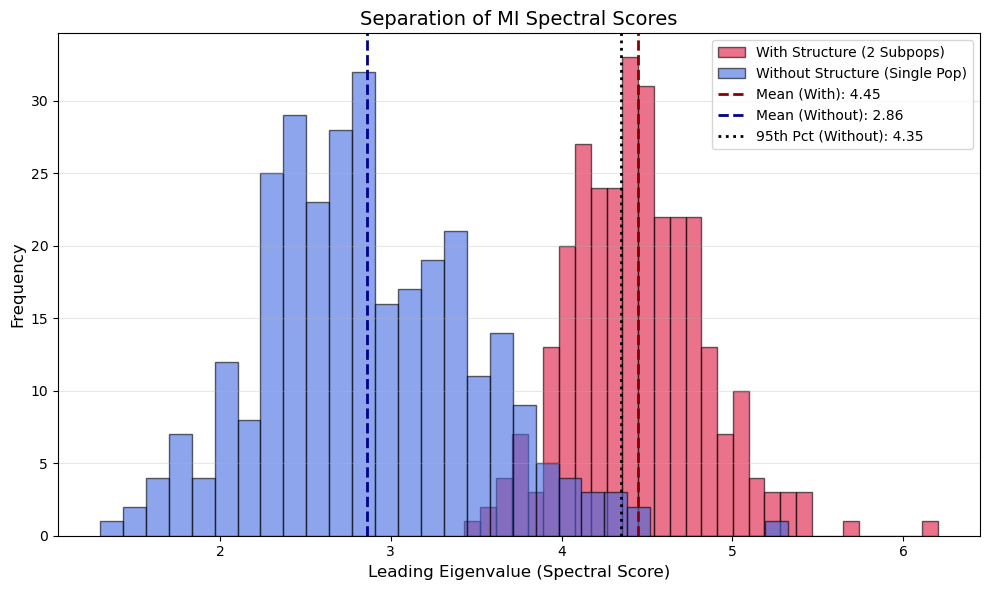

In [249]:
import matplotlib.pyplot as plt
import numpy as np

# Print the requested statistics
mean_with = np.mean(with_structure)
mean_without = np.mean(without_structure)

# Calculate the 95th percentile of the 'without' distribution
threshold_95 = np.percentile(without_structure, 99)

# Calculate what fraction of the 'with' distribution is above that threshold
# This represents the "True Positive Rate" or "Power" at a 5% False Positive Rate
fraction_above = np.mean(with_structure > threshold_95)

print(f"Mean (With Structure):    {mean_with:.5f}")
print(f"Mean (Without Structure): {mean_without:.5f}")
print(f"95th Percentile of 'Without': {threshold_95:.5f}")
print(f"Fraction of 'With' above 'Without' 95th Pct: {fraction_above:.2%}")

# Create the plot
plt.figure(figsize=(10, 6))

# Plot histograms
plt.hist(with_structure, bins=30, alpha=0.6, label='With Structure (2 Subpops)', color='crimson', edgecolor='black')
plt.hist(without_structure, bins=30, alpha=0.6, label='Without Structure (Single Pop)', color='royalblue', edgecolor='black')

# Add vertical lines for the means
plt.axvline(mean_with, color='darkred', linestyle='dashed', linewidth=2, label=f'Mean (With): {mean_with:.2f}')
plt.axvline(mean_without, color='darkblue', linestyle='dashed', linewidth=2, label=f'Mean (Without): {mean_without:.2f}')

# Add a vertical line for the 95th percentile threshold
plt.axvline(threshold_95, color='black', linestyle='dotted', linewidth=2, label=f'95th Pct (Without): {threshold_95:.2f}')

# Formatting
plt.title('Separation of MI Spectral Scores', fontsize=14)
plt.xlabel('Leading Eigenvalue (Spectral Score)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()